In [5]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

#carregando o dataset
OASIS_PREPARED_PATH = os.path.join("..", "data", "interim", "oasis_prepared.csv")
def load_oasis_data(path = OASIS_PREPARED_PATH):
    return pd.read_csv(path)

data = load_oasis_data()

#dividindo em X e y
X = data.drop(columns=['Risk.Group'])
y = data['Risk.Group']

print("Dimensões de X: ", X.shape)
print(pd.Series(y).value_counts())

Dimensões de X:  (5150, 7)
Risk.Group
1    2578
0    2572
Name: count, dtype: int64


In [6]:
#pré-processamento
numerical_cols = X.columns

#pipeline que primeiro preenche os números, depois normaliza
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

#ColumnTransformer permite aplicar pré-processamentos diferentes em atributos numéricos e categóricos, o que é útil para novos tipos de colunas que venham a surgir no dataset
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols)
    ]
)

#divisão estratificada entre dados de teste e de treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#iniciando o spotchecking de modelos
models = {
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "DecisionTree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "NeuralNetwork": MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=10, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

results = {}
results_raw = {}

print("Spot Checking:")
for name, model in models.items():
    pipeline = Pipeline([
        ("processing", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    results_raw[name] = scores
    results[name] = {
        "mean": scores.mean(),
        "std": scores.std()
    }

    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Spot Checking:
KNN: Mean=0.8049, Std=0.0199
LogisticRegression: Mean=0.8158, Std=0.0270
DecisionTree: Mean=0.7926, Std=0.0260
NeuralNetwork: Mean=0.8042, Std=0.0313
RandomForest: Mean=0.8243, Std=0.0277


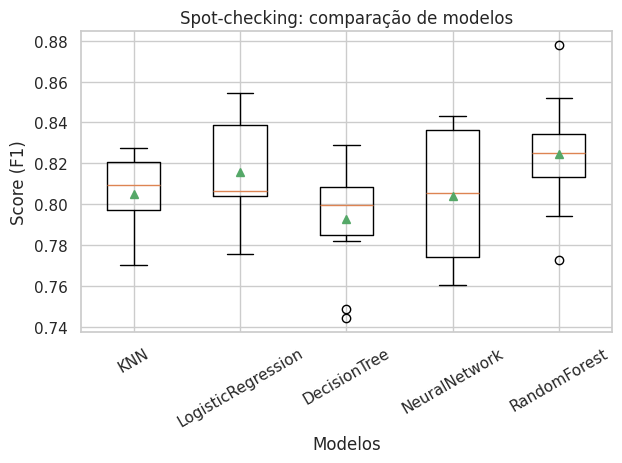

In [7]:
plt.figure()
plt.boxplot([results_raw[m] for m in results_raw.keys()], tick_labels=list(results_raw.keys()),showmeans=True)
plt.title("Spot-checking: comparação de modelos")
plt.xlabel("Modelos")
plt.ylabel("Score (F1)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [8]:
#converter resultados em dataframe para análise
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="mean", ascending=False)
print(results_df)

                        mean       std
RandomForest        0.824348  0.027705
LogisticRegression  0.815753  0.027038
KNN                 0.804905  0.019936
NeuralNetwork       0.804164  0.031349
DecisionTree        0.792640  0.026041


com base na média gerada pelos modelos, escolhemos RandomForest e LogisticRegression para a otimização de hiperparâmetros

In [9]:
#agora sim, otimização de hiperparâmetros

#grid de parametros para a floresta aleatória
param_grid = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True]
}

#pipeline para RandomForest
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier())
])

cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

# Inner CV (tuning)
inner_cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

# Outer CV (avaliação do modelo otimizado)
outer_cv = cv

search_nested = GridSearchCV(
    pipeline,
    param_grid, 
    cv=inner_cv,
    scoring='f1',
    refit=True
)

nested_scores = cross_validate(
    search_nested,
    X_train,
    y_train,
    cv=outer_cv,
    scoring='f1',
    return_estimator=True,
    return_train_score=True,
    verbose=1,
)


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed: 18.0min finished


In [10]:
nested_mean = nested_scores['test_score'].mean()
nested_std = nested_scores['test_score'].std()

print(f"Nested CV - Mean: {nested_mean:.4f}, Std: {nested_std:.4f}")


Nested CV - Mean: 0.8265, Std: 0.0278


In [12]:
[x.best_params_ for x in nested_scores['estimator']]

[{'model__bootstrap': True,
  'model__max_depth': None,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 10,
  'model__n_estimators': 200},
 {'model__bootstrap': True,
  'model__max_depth': None,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 10,
  'model__n_estimators': 200},
 {'model__bootstrap': True,
  'model__max_depth': None,
  'model__min_samples_leaf': 4,
  'model__min_samples_split': 5,
  'model__n_estimators': 200},
 {'model__bootstrap': True,
  'model__max_depth': None,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 5,
  'model__n_estimators': 500},
 {'model__bootstrap': True,
  'model__max_depth': 20,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 10,
  'model__n_estimators': 200},
 {'model__bootstrap': True,
  'model__max_depth': 20,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 2,
  'model__n_estimators': 200},
 {'model__bootstrap': True,
  'model__max_depth': 20,
  'model__min_samples_leaf': 1,
  '

Melhores hiperparâmetros (os que mais aparecem):
bootstrap: True
max_depth: None
min_samples_leaf: 2
min_samples_split: 10
n_estimators: 200

In [ ]:
#configurando o modelo com os hiperparâmetros escolhidos
modelo_final = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=10,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

# treino do modelo final
modelo_final.fit(X_train, y_train)



,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


=== PERFORMANCE FINAL NO CONJUNTO DE TESTE ===
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       772
           1       0.90      0.75      0.82       773

    accuracy                           0.84      1545
   macro avg       0.85      0.84      0.83      1545
weighted avg       0.85      0.84      0.83      1545



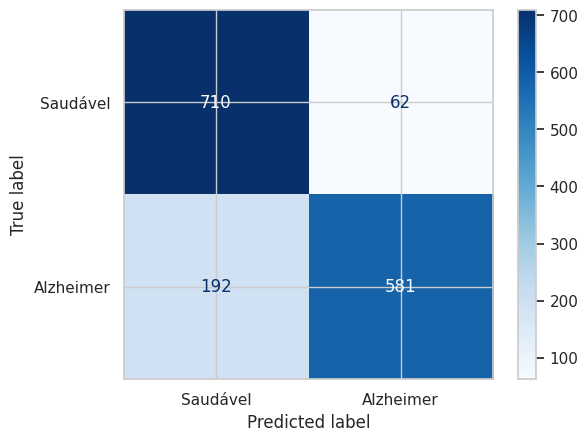

In [ ]:
#fazendo as predições
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1] #probabilidade

#relatório de performance
print("=== PERFORMANCE FINAL NO CONJUNTO DE TESTE ===")
print(classification_report(y_test, y_pred))

# 3. Matriz de Confusão Visual
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', display_labels=['Saudável', 'Alzheimer'])
plt.show()

In [15]:
import joblib

# Salva o modelo treinado em um arquivo físico
joblib.dump(modelo_final, 'modelo_final_neuropredict.pkl')
print("Arquivo 'modelo_final_neuropredict.pkl' gerado com sucesso!")

Arquivo 'modelo_final_neuropredict.pkl' gerado com sucesso!
